**Predictions for CDK**

**Acess To Drive and Libraries - For Google Colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Import libraries
import pyarrow.parquet as pq
from google.colab import files
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error

Mounted at /content/drive


**Uploading - For Google Colab**

In [ ]:
uploaded = files.upload()#KB79141

Saving active_imported.parquet to active_imported.parquet
Saving reactive_exported.parquet to reactive_exported.parquet
Saving reactive_imported.parquet to reactive_imported.parquet


**Loading and Plotting Data**

[np.float64(550.0), np.float64(670.0), np.float64(730.0), np.float64(600.0), np.float64(1780.0), np.float64(1920.0), np.float64(2930.0), np.float64(1530.0), np.float64(470.0), np.float64(460.0), np.float64(510.0), np.float64(670.0), np.float64(350.0), np.float64(400.0), np.float64(530.0), np.float64(580.0), np.float64(540.0), np.float64(480.0), np.float64(350.0), np.float64(420.0), np.float64(380.0), np.float64(390.0), np.float64(520.0), np.float64(620.0), np.float64(690.0), np.float64(1490.0), np.float64(630.0), np.float64(750.0), np.float64(760.0), np.float64(760.0), np.float64(720.0), np.float64(580.0), np.float64(580.0), np.float64(600.0), np.float64(540.0), np.float64(790.0), np.float64(910.0), np.float64(720.0), np.float64(810.0), np.float64(560.0), np.float64(630.0), np.float64(410.0), np.float64(360.0), np.float64(380.0), np.float64(420.0), np.float64(340.0), np.float64(350.0), np.float64(550.0), np.float64(640.0), np.float64(550.0), np.float64(620.0), np.float64(770.0), np.flo

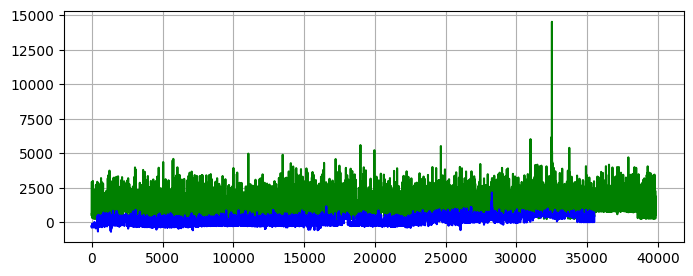

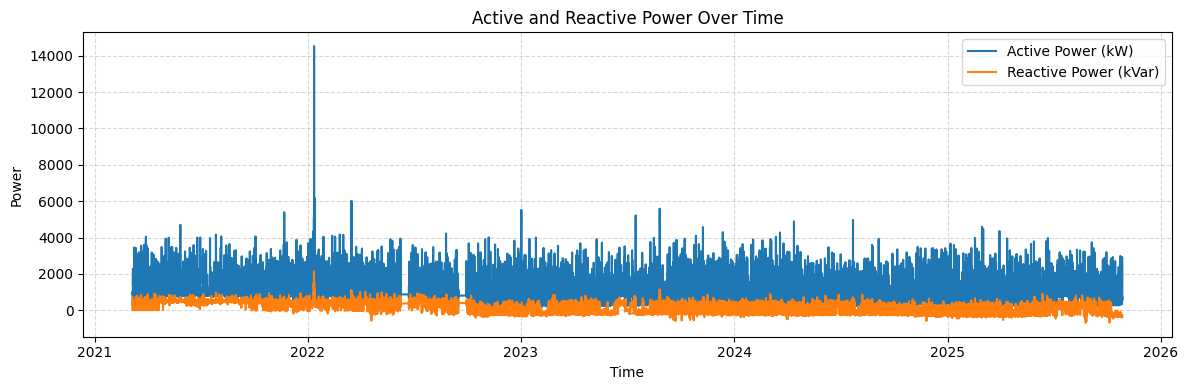

In [ ]:
Active_exported = []#pq.read_table('active_exported.parquet').to_pandas()# For Nodes with 3 data files: []
Active_imported = pq.read_table('active_imported.parquet').to_pandas()
Reractive_exported = pq.read_table('reactive_exported.parquet').to_pandas()
Reactive_imported = pq.read_table('reactive_imported.parquet').to_pandas()

# Effective length = minimum length of the two datasets
AIL = max(len(Active_imported), len(Active_exported))
RIL = max(len(Reactive_imported), len(Reractive_exported))

Active_total = []
Reactive_total = []

# ---- Active power ----
for i in range(AIL):
    # Use 0 if index is out of range
    imp = Active_imported['value'].iloc[i] if i < len(Active_imported) else 0
    exp = Active_exported['value'].iloc[i] if i < len(Active_exported) else 0
    Active_total.append(imp - exp)
print(Active_total)
# ---- Reactive power ----
for i in range(RIL):
    imp = Reactive_imported['value'].iloc[i] if i < len(Reactive_imported) else 0
    exp = Reractive_exported['value'].iloc[i] if i < len(Reractive_exported) else 0
    Reactive_total.append(imp - exp)

#Plotting 1
fig,ax = plt.subplots()
plt.rcParams["figure.figsize"] = (8, 3)
ax.plot(Active_total[0:AIL],color="green", label="Active power")
ax.plot(Reactive_total[0:RIL],color="blue", label="Reactive power")
ax.grid()
plt.show()


# Plotting 2
time_A = Active_imported['timestamp'][:AIL]
time_R = Reactive_imported['timestamp'][:RIL]

fig, ax = plt.subplots(figsize=(12, 4))

# Active
LA = min(len(time_A), len(Active_total))
ax.plot(time_A[:LA], Active_total[:LA], label="Active Power (kW)")

# Reactive
LR = min(len(time_R), len(Reactive_total))
ax.plot(time_R[:LR], Reactive_total[:LR], label="Reactive Power (kVar)")

ax.set_xlabel("Time")
ax.set_ylabel("Power")
ax.set_title("Active and Reactive Power Over Time")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

**Sorting Data 1:**
Sorting 1 focuses on aligning the imported timestamps with the total energy arrays (Active_total and Reactive_total), even when the lengths do not match. If the imported timestamp list is shorter, the code pads the missing timestamps with NaT (Not-a-Time) so that its length matches the total measurement list. If it is longer, it trims the timestamp list to the correct length. Then it constructs two DataFrames (df_active and df_reactive) where the index is the timestamp and the column contains the corresponding total energy values. Finally, the code prints the head and tail to visually inspect how well the timestamps align with the data.

In [ ]:
# ---- Active ----
# Extend timestamps if Active_imported is shorter than Active_total
if len(Active_imported) < len(Active_total):
    extra_len = len(Active_total) - len(Active_imported)
    # create NaT timestamps for padding
    extra_ts = pd.Series([pd.NaT]*extra_len)
    timestamps_active = pd.concat([Active_imported["timestamp"].reset_index(drop=True), extra_ts], ignore_index=True)
else:
    timestamps_active = Active_imported["timestamp"].iloc[:len(Active_total)].reset_index(drop=True)

df_active = pd.DataFrame({"Active_total": Active_total}, index=timestamps_active)
df_active.index.name = "timestamp"

# ---- Reactive ----
if len(Reactive_imported) < len(Reactive_total):
    extra_len = len(Reactive_total) - len(Reactive_imported)
    extra_ts = pd.Series([pd.NaT]*extra_len)
    timestamps_reactive = pd.concat([Reactive_imported["timestamp"].reset_index(drop=True), extra_ts], ignore_index=True)
else:
    timestamps_reactive = Reactive_imported["timestamp"].iloc[:len(Reactive_total)].reset_index(drop=True)

df_reactive = pd.DataFrame({"Reactive_total": Reactive_total}, index=timestamps_reactive)
df_reactive.index.name = "timestamp"

# ---- Show head and tail ----
print("=== Active_total HEAD (20) ===")
display(df_active.head(3))

print("=== Active_total TAIL (20) ===")
display(df_active.tail(3))

print("=== Reactive_total HEAD (20) ===")
display(df_reactive.head(3))

print("=== Reactive_total TAIL (20) ===")
display(df_reactive.tail(3))

=== Active_total HEAD (20) ===


,Active_total
timestamp,
2025-10-26 23:00:00+00:00,550.0
2025-10-26 22:00:00+00:00,670.0
2025-10-26 21:00:00+00:00,730.0


=== Active_total TAIL (20) ===


,Active_total
timestamp,
2021-03-07 02:00:00+00:00,600.0
2021-03-07 01:00:00+00:00,1020.0
2021-03-07 00:00:00+00:00,930.0


=== Reactive_total HEAD (20) ===


,Reactive_total
timestamp,
2025-10-26 23:00:00+00:00,-290.0
2025-10-26 22:00:00+00:00,-290.0
2025-10-26 19:00:00+00:00,-320.0


=== Reactive_total TAIL (20) ===


,Reactive_total
timestamp,
2021-03-07 02:00:00+00:00,100.0
2021-03-07 01:00:00+00:00,420.0
2021-03-07 00:00:00+00:00,410.0


**Sorting Data 2 - Cleans, reindexes hourly, and interpolates to create a continuous time series.**
Sorting 2 converts the index into proper datetime objects and removes duplicated timestamps by averaging them. It then sorts the timestamps and creates a continuous hourly index from the earliest to the latest date in both datasets. The DataFrames are reindexed onto this full hourly timeline, which introduces missing rows for hours without measurements. Finally, missing values are filled using linear interpolation with forward and backward filling, producing smooth, complete hourly time series for both Active and Reactive energy.

In [ ]:
# --- Ensure index is datetime ---
df_active.index = pd.to_datetime(df_active.index)
df_reactive.index = pd.to_datetime(df_reactive.index)

# --- Remove duplicates by taking the mean of duplicates ---
df_active = df_active.groupby(df_active.index).mean()
df_reactive = df_reactive.groupby(df_reactive.index).mean()

# --- Sort by timestamp ---
df_active = df_active.sort_index()
df_reactive = df_reactive.sort_index()

# --- Create a continuous hourly datetime index covering full range ---
full_index = pd.date_range(
    start=min(df_active.index.min(), df_reactive.index.min()),
    end=max(df_active.index.max(), df_reactive.index.max()),
    freq="H"
)

# --- Reindex both DataFrames to full_index ---
df_active = df_active.reindex(full_index)
df_reactive = df_reactive.reindex(full_index)

# --- Interpolate missing values linearly ---
df_active["Active_total"] = df_active["Active_total"].interpolate().ffill().bfill()
df_reactive["Reactive_total"] = df_reactive["Reactive_total"].interpolate().ffill().bfill()

# --- Set the index name ---
df_active.index.name = "timestamp"
df_reactive.index.name = "timestamp"

# --- Check first 20 rows ---
print(df_active.head(3))
print(df_active.tail(3))
print(df_reactive.head(3))
print(df_reactive.tail(3))

                           Active_total
timestamp                              
2021-03-07 00:00:00+00:00         930.0
2021-03-07 01:00:00+00:00        1020.0
2021-03-07 02:00:00+00:00         600.0
                           Active_total
timestamp                              
2025-10-26 21:00:00+00:00         730.0
2025-10-26 22:00:00+00:00         670.0
2025-10-26 23:00:00+00:00         550.0
                           Reactive_total
timestamp                                
2021-03-07 00:00:00+00:00           410.0
2021-03-07 01:00:00+00:00           420.0
2021-03-07 02:00:00+00:00           100.0
                           Reactive_total
timestamp                                
2025-10-26 21:00:00+00:00          -300.0
2025-10-26 22:00:00+00:00          -290.0
2025-10-26 23:00:00+00:00          -290.0


**Predictors Function - You can select each method you want.** Use this line which currently uses knn method: "    if predictor is None:
        predictor = LoadPredictor1(method="knn", history_window=24)"

In [ ]:
# === LoadPredictors ===
class LoadPredictor1:
    def __init__(self, method, history_window=24):
        self.method = method
        self.history_window = history_window
        self.model = None

    def prepare_data(self, siteLoad):
        X, y = [], []
        for t in range(self.history_window, len(siteLoad)):
            X.append(siteLoad[t-self.history_window:t])
            y.append(siteLoad[t])
        return np.array(X), np.array(y)


    def train(self, siteLoad):
        X, y = self.prepare_data(siteLoad)
        if self.method == "linear":
            self.model = LinearRegression()
        elif self.method == "mlp":
            self.model = MLPRegressor(hidden_layer_sizes=(32,16), max_iter=500)
        elif self.method == "tree":
            self.model = DecisionTreeRegressor(max_depth=10)
        elif self.method == "rf":
            self.model = RandomForestRegressor(n_estimators=200)
        elif self.method == "xgb":
            self.model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
        elif self.method == "knn":
            self.model = KNeighborsRegressor(n_neighbors=5)
        elif self.method == "ensemble1":
            tree = DecisionTreeRegressor(max_depth=10)
            rf   = RandomForestRegressor(n_estimators=100)
            xgb  = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
            self.model = VotingRegressor([("tree", tree), ("rf", rf), ("xgb", xgb)])
        elif self.method == "ensemble2":
            rf   = RandomForestRegressor(n_estimators=200)
            xgb  = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
            self.model = VotingRegressor([("rf", rf), ("xgb", xgb)])
        elif self.method == "ensemble3":
            rf   = RandomForestRegressor(n_estimators=200)
            xgb  = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
            ens  = VotingRegressor([("rf2", RandomForestRegressor(n_estimators=150)), ("xgb2", XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=5))])
            self.model = VotingRegressor([("rf", rf), ("xgb", xgb), ("ens", ens)])
        elif self.method == "ensemble4":
            tree = DecisionTreeRegressor(max_depth=30)
            rf   = RandomForestRegressor(n_estimators=200)
            xgb  = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
            ens  = VotingRegressor([("rf2", RandomForestRegressor(n_estimators=150)), ("xgb2", XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=5))])
            self.model = VotingRegressor([("tree", tree),("rf", rf), ("xgb", xgb), ("ens", ens)])
        elif self.method == "ensemble5":
            knn = KNeighborsRegressor(n_neighbors=20)
            tree = DecisionTreeRegressor(max_depth=30)
            rf   = RandomForestRegressor(n_estimators=200)
            xgb  = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
            ens  = VotingRegressor([("rf2", RandomForestRegressor(n_estimators=150)), ("xgb2", XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=5))])
            self.model = VotingRegressor([("knn", knn), ("tree", tree), ("rf", rf), ("xgb", xgb), ("ens", ens)])
        else:
            raise ValueError("Unknown method")
        self.model.fit(X, y)

    def predict(self, siteLoad, t_now, look_ahead=1):
        hist = siteLoad[max(0, t_now - self.history_window + 1): t_now + 1].tolist()
        while len(hist) < self.history_window:
            hist = [siteLoad[0]] + hist
        preds = []
        for _ in range(look_ahead):
            x_input = np.array(hist[-self.history_window:]).reshape(1, -1)
            next_val = self.model.predict(x_input)[0]
            preds.append(next_val)
            hist.append(next_val)
        return preds

# Train predictor once before MPC
def predict_24h_safe(df, target_time, predictor=None):
    """
    Predict 24 hours ahead using previous week, safely handling missing data.
    """
    if predictor is None:
        predictor = LoadPredictor1(method="xgb", history_window=24)

    # 1 week of data before target_time
    start_train = target_time - pd.Timedelta(days=7)

    # Slice data, fill missing timestamps with 0
    mask = (df.index > start_train) & (df.index <= target_time)
    train_series = df.loc[mask, df.columns[0]]

    if len(train_series) == 0:
        raise ValueError("No training data available in the past week before target_time.")

    train_series.index = pd.to_datetime(train_series.index)  # ensure datetime index

    train_data = train_series.interpolate(method='time').ffill().bfill().values
    #train_data = train_series.ffill().bfill().values#fillna(0)
    #siteLoad = df_filtered['siteLoad'][:time_horizon+20].ffill().bfill().to_numpy()
    #price_base = df_filtered['Spot_price'][:time_horizon].ffill().bfill().to_numpy()


    # Train predictor
    predictor.train(train_data)

    # Predict next 24 hours
    t_now = len(train_data) - 1
    preds = predictor.predict(train_data, t_now, look_ahead=24)

    # Prepare timestamps for prediction
    pred_index = pd.date_range(start=target_time + pd.Timedelta(hours=1), periods=24, freq='H')
    df_pred = pd.DataFrame({f"Predicted_{df.columns[0]}": preds}, index=pred_index)

    return df_pred

**Active Prediction**

,Actual_Active,Predicted_Active
timestamp,,
2025-09-30 01:00:00+00:00,720.0,534.292857
2025-09-30 02:00:00+00:00,780.0,437.513787
2025-09-30 03:00:00+00:00,560.0,434.428460
2025-09-30 04:00:00+00:00,450.0,568.680658
2025-09-30 05:00:00+00:00,760.0,738.190449
2025-09-30 06:00:00+00:00,490.0,737.495382
2025-09-30 07:00:00+00:00,790.0,904.661818
2025-09-30 08:00:00+00:00,580.0,829.300854
2025-09-30 09:00:00+00:00,1110.0,946.608630


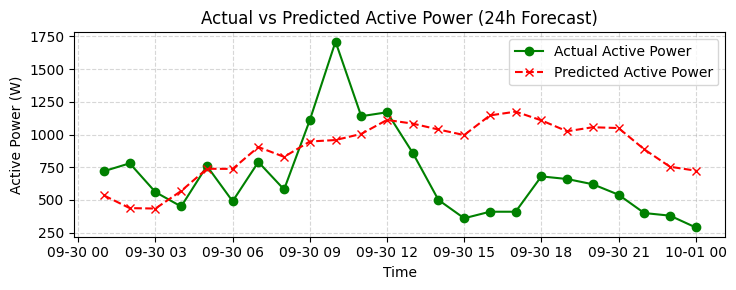

In [ ]:
#Prediction
target_time = pd.Timestamp("2025-09-30 00:00:00+00:00")

# 24h prediction
df_24h_pred = predict_24h_safe(df_active, target_time)


# Slice actual values safely (if any exist)
start_pred = df_24h_pred.index[0]
end_pred   = df_24h_pred.index[-1]

actual_24h = df_active.reindex(df_24h_pred.index)["Active_total"]


# Combine into one DataFrame
df_compare = pd.DataFrame({
    "Actual_Active": actual_24h.values,       # will be NaN if missing
    "Predicted_Active": df_24h_pred.iloc[:,0].values
}, index=df_24h_pred.index)

df_compare.index.name = "timestamp"

display(df_compare)

# df_compare already has Actual_Active and Predicted_Active
plt.figure(figsize=(7.5, 3))

# Actual values (NaNs will create gaps)
plt.plot(df_compare.index, df_compare["Actual_Active"], label="Actual Active Power", color="green", marker='o')

# Predicted values
plt.plot(df_compare.index, df_compare["Predicted_Active"], label="Predicted Active Power", color="red", linestyle='--', marker='x')

plt.xlabel("Time")
plt.ylabel("Active Power (W)")
plt.title("Actual vs Predicted Active Power (24h Forecast)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Reactive Prediction**

,Actual_Reactive,Predicted_Reactive
timestamp,,
2025-09-30 01:00:00+00:00,400.000000,281.491913
2025-09-30 02:00:00+00:00,350.000000,178.845871
2025-09-30 03:00:00+00:00,90.000000,200.150070
2025-09-30 04:00:00+00:00,-220.000000,180.708359
2025-09-30 05:00:00+00:00,-203.333333,160.469681
2025-09-30 06:00:00+00:00,-186.666667,193.916611
2025-09-30 07:00:00+00:00,-170.000000,132.359924
2025-09-30 08:00:00+00:00,-220.000000,142.922653
2025-09-30 09:00:00+00:00,-80.000000,137.283051


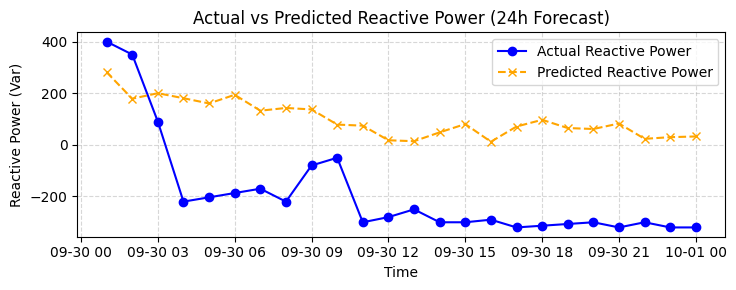

In [ ]:
# --- Step 1: Make Reactive DataFrame index unique ---
# Sum values if there are duplicate timestamps
df_reactive_unique = df_reactive.groupby(df_reactive.index).mean()#sum()

# --- Step 2: Predict 24h ahead ---
df_24h_pred = predict_24h_safe(df_reactive_unique, target_time)

# --- Step 3: Slice actual values safely for the prediction period ---
start_pred = df_24h_pred.index[0]
end_pred   = df_24h_pred.index[-1]

# Reindex actual data to match prediction timestamps; missing values become NaN
actual_24h = df_reactive_unique.reindex(df_24h_pred.index)["Reactive_total"]

# --- Step 4: Combine predicted + actual into one DataFrame ---
df_compare_reactive = pd.DataFrame({
    "Actual_Reactive": actual_24h.values,       # NaN if missing
    "Predicted_Reactive": df_24h_pred.iloc[:,0].values
}, index=df_24h_pred.index)

df_compare_reactive.index.name = "timestamp"

# --- Step 5: Display table ---
display(df_compare_reactive)

# --- Step 6: Plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7.5, 3))
plt.plot(df_compare_reactive.index, df_compare_reactive["Actual_Reactive"],
         label="Actual Reactive Power", color="blue", marker='o')
plt.plot(df_compare_reactive.index, df_compare_reactive["Predicted_Reactive"],
         label="Predicted Reactive Power", color="orange", linestyle='--', marker='x')

plt.xlabel("Time")
plt.ylabel("Reactive Power (Var)")
plt.title("Actual vs Predicted Reactive Power (24h Forecast)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()